### Libraries

In [1]:
# ── Data & Numerics 
import numpy as np
import pandas as pd
# ── Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

import importlib
from Modules import visual, config
# reload modules
importlib.reload(visual)
importlib.reload(config)

<module 'Modules.config' from '/home/fedde/Projects/data_science_kit/Modules/config.py'>

### Example1 - shankey

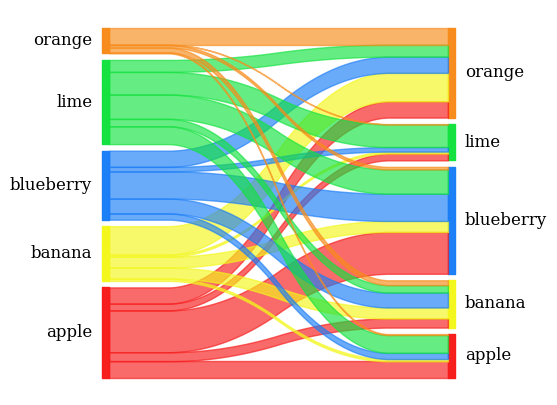

In [8]:
pd.options.display.max_rows = 8

df = pd.read_csv('datasets/fruits.txt', 
                 sep = ' ', 
                 names= ['true', 'predicted'])

df = df.sort_values(by = ['true', 'predicted'])

colorDict = {
    'apple':'#f71b1b',
    'blueberry':'#1b7ef7',
    'banana':'#f3f71b',
    'lime':'#12e23f',
    'orange':'#f78c1b'
}

fig, ax = plt.subplots(figsize = (5,5))
visual.sankey_df(df, colorDict, ax= ax)

### Example2 - heatmap plotting

In [11]:
#!pip install yfinance

In [14]:
import yfinance as yf
df = yf.download("AAPL", start="2019-01-01", end="2026-01-01")
df.head(2)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.503723,37.724587,36.627401,36.784142,148158800
2019-01-03,33.768070,34.606394,33.722947,34.193168,365248800


In [15]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.503723,37.724587,36.627401,36.784142,148158800
2019-01-03,33.768070,34.606394,33.722947,34.193168,365248800
2019-01-04,35.209614,35.278487,34.150430,34.323794,234428400
2019-01-07,35.131245,35.344984,34.649149,35.314110,219111200
...,...,...,...,...,...
2025-12-26,273.144409,275.112569,272.604905,273.903708,21521800
2025-12-29,273.504089,274.103504,272.095404,272.435082,23715200
2025-12-30,272.824707,273.823772,272.025467,272.554970,22139600


/tmp/ipykernel_20340/312095943.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab20', len(countries))


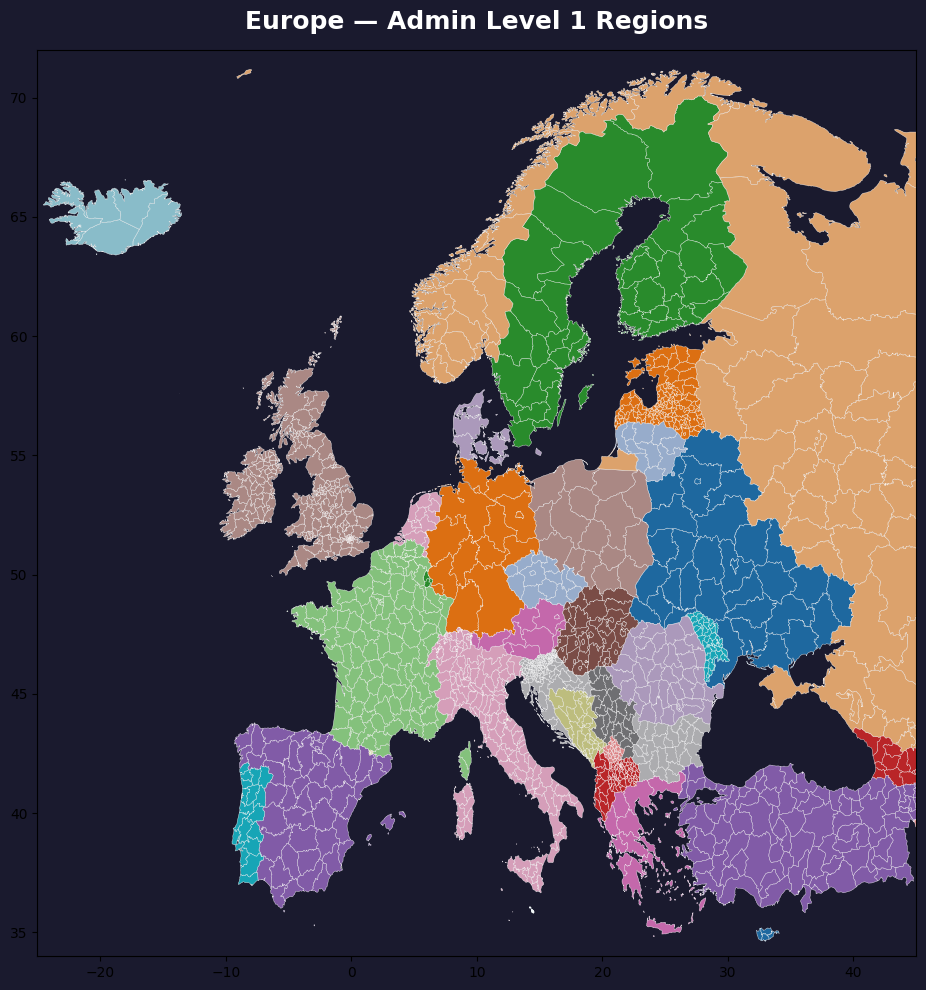

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Natural Earth admin-1 (states/provinces = GADM level 1 equivalent)
url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_10m_admin_1_states_provinces.geojson"
gdf = gpd.read_file(url)

# European sovereign ISO codes
europe_iso = {
    'AL','AD','AT','BY','BE','BA','BG','HR','CY','CZ','DK','EE','FI','FR',
    'DE','GR','HU','IS','IE','IT','XK','LV','LI','LT','LU','MT','MD','MC',
    'ME','NL','MK','NO','PL','PT','RO','RU','SM','RS','SK','SI','ES','SE',
    'CH','TR','UA','GB','VA','AZ','AM','GE'
}

eu = gdf[gdf['iso_a2'].isin(europe_iso)].copy()
eu = eu.cx[-25:45, 34:72]  # crop to Europe bounding box

# Color by country
import matplotlib.cm as cm
countries = eu['iso_a2'].unique()
cmap = cm.get_cmap('tab20', len(countries))
color_map = {c: cmap(i) for i, c in enumerate(countries)}
eu['color'] = eu['iso_a2'].map(color_map)

fig, ax = plt.subplots(figsize=(14, 10), facecolor='#1a1a2e')
ax.set_facecolor('#1a1a2e')
eu.plot(ax=ax, color=eu['color'].tolist(), edgecolor='white', linewidth=0.3, alpha=0.85)
ax.set_xlim(-25, 45); ax.set_ylim(34, 72)
ax.set_title('', fontsize=18, color='white', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


In [2]:
import geopandas as gpd

# After downloading e.g. gadm41_ITA.gpkg from https://gadm.org/download_country.html
gdf_l0 = gpd.read_file("gadm41_ITA.gpkg", layer="ADM_ADM_0")  # country outline
gdf_l1 = gpd.read_file("gadm41_ITA.gpkg", layer="ADM_ADM_1")  # regions (Lombardia, Lazio, etc.)
gdf_l2 = gpd.read_file("gadm41_ITA.gpkg", layer="ADM_ADM_2")  # provinces

# Quick plot of Italian regions
fig, ax = plt.subplots(figsize=(8, 10))
gdf_l1.plot(ax=ax, edgecolor='black', linewidth=0.5, cmap='tab20', column='NAME_1')
for _, row in gdf_l1.iterrows():
    ax.annotate(row['NAME_1'], xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                ha='center', fontsize=7)
ax.set_title('Italian Regions (GADM Level 1)')
ax.axis('off')
plt.tight_layout()
plt.show()

DriverError: gadm41_ITA.gpkg: No such file or directory

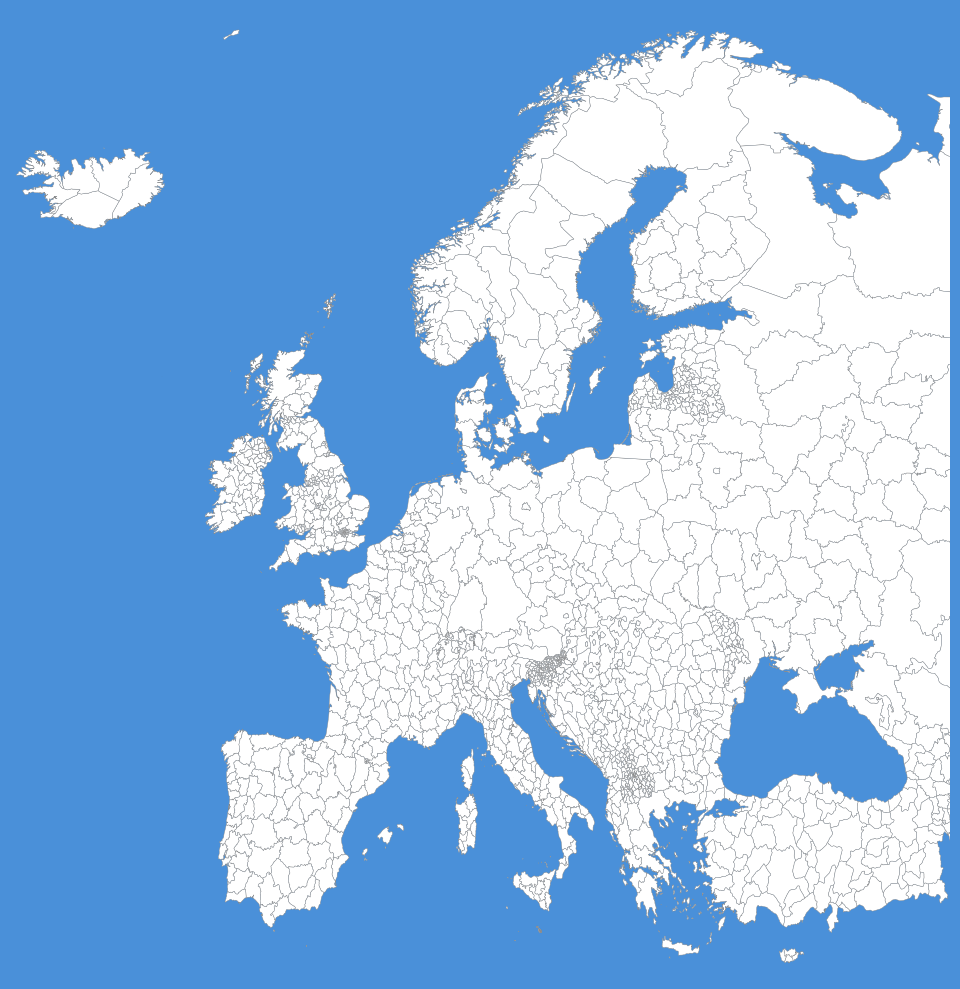

In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_10m_admin_1_states_provinces.geojson"
gdf = gpd.read_file(url)

europe_iso = {
    'AL','AD','AT','BY','BE','BA','BG','HR','CY','CZ','DK','EE','FI','FR',
    'DE','GR','HU','IS','IE','IT','XK','LV','LI','LT','LU','MT','MD','MC',
    'ME','NL','MK','NO','PL','PT','RO','RU','SM','RS','SK','SI','ES','SE',
    'CH','TR','UA','GB','VA','AZ','AM','GE'
}

eu = gdf[gdf['iso_a2'].isin(europe_iso)].copy()
eu = eu.cx[-25:45, 34:72]

# Regions to highlight — check exact names with: eu[eu['iso_a2']=='IT']['name'].tolist()
highlight = {'Sardegna', 'Piemonte'}
eu['color'] = eu['name'].apply(lambda x: 'red' if x in highlight else 'white')

fig, ax = plt.subplots(figsize=(14, 10), facecolor='#4a90d9')  # sea = blue background
ax.set_facecolor('#4a90d9')

eu.plot(ax=ax, color=eu['color'].tolist(), edgecolor='#888888', linewidth=0.3)

ax.set_xlim(-25, 45)
ax.set_ylim(34, 72)
ax.axis('off')
plt.tight_layout()
plt.show()

In [16]:
import geopandas as gpd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_10m_admin_1_states_provinces.geojson"
gdf = gpd.read_file(url)

europe_iso = {
    'AL','AD','AT','BY','BE','BA','BG','HR','CY','CZ','DK','EE','FI','FR',
    'DE','GR','HU','IS','IE','IT','XK','LV','LI','LT','LU','MT','MD','MC',
    'ME','NL','MK','NO','PL','PT','RO','RU','SM','RS','SK','SI','ES','SE',
    'CH','TR','UA','GB','VA','AZ','AM','GE'
}

eu = gdf[gdf['iso_a2'].isin(europe_iso)].copy()
eu = eu.cx[-25:45, 34:72]

sardinia  = {'Cagliari', 'Carbonia-Iglesias', 'Medio Campidano',
             'Nuoro', 'Ogliastra', 'Olbia-Tempio', 'Oristrano', 'Sassari'}

piedmont  = {'Alessandria', 'Asti', 'Biella', 'Cuneo',
             'Novara', 'Turin', 'Verbano-Cusio-Ossola', 'Vercelli'}

sjaelland = {'Sjaælland', 'Hovedstaden'}

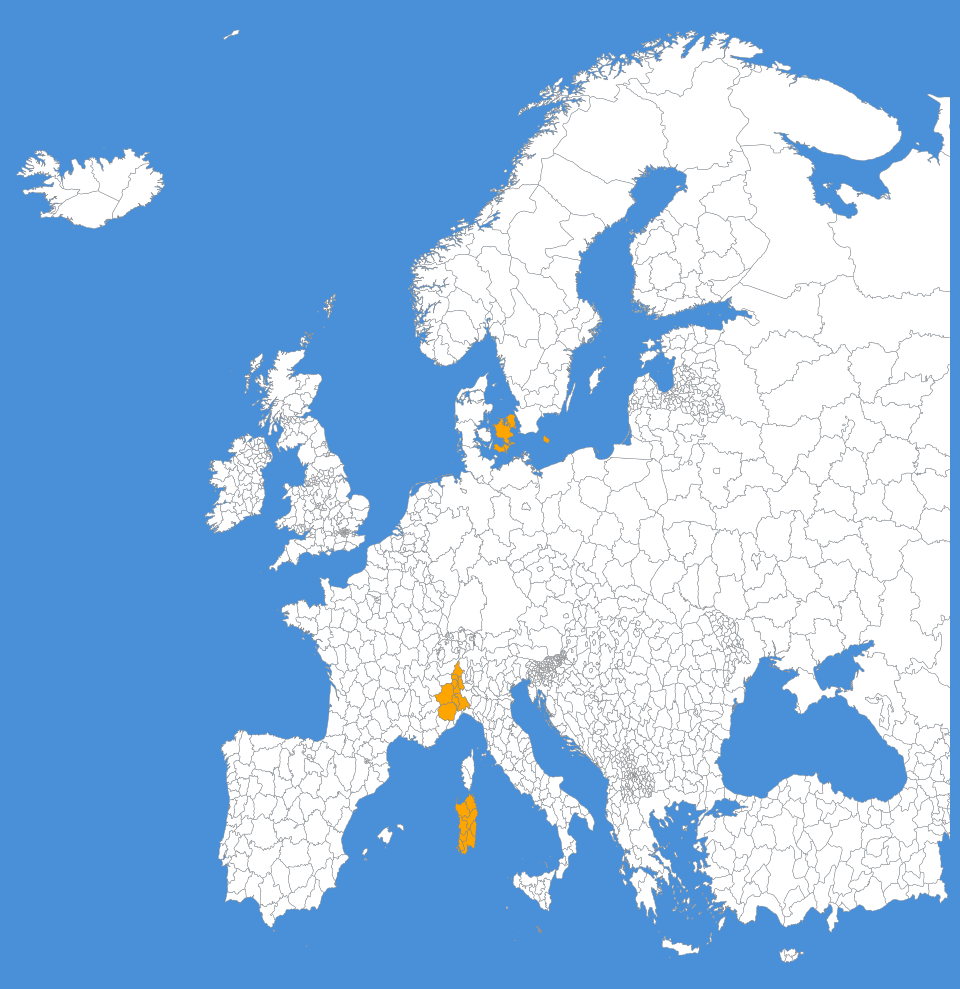

In [19]:
highlight = sardinia | piedmont | sjaelland

eu['color'] = eu['name'].apply(lambda x: 'orange' if x in highlight else 'white')

fig, ax = plt.subplots(figsize=(15, 10), facecolor='#4a90d9')
ax.set_facecolor('#4a90d9')
eu.plot(ax=ax, color=eu['color'].tolist(), edgecolor='#888888', linewidth=0.3, aspect = 'auto')
ax.set_xlim(-25, 45)
ax.set_ylim(34, 72)
ax.axis('off')
plt.tight_layout()
plt.show()

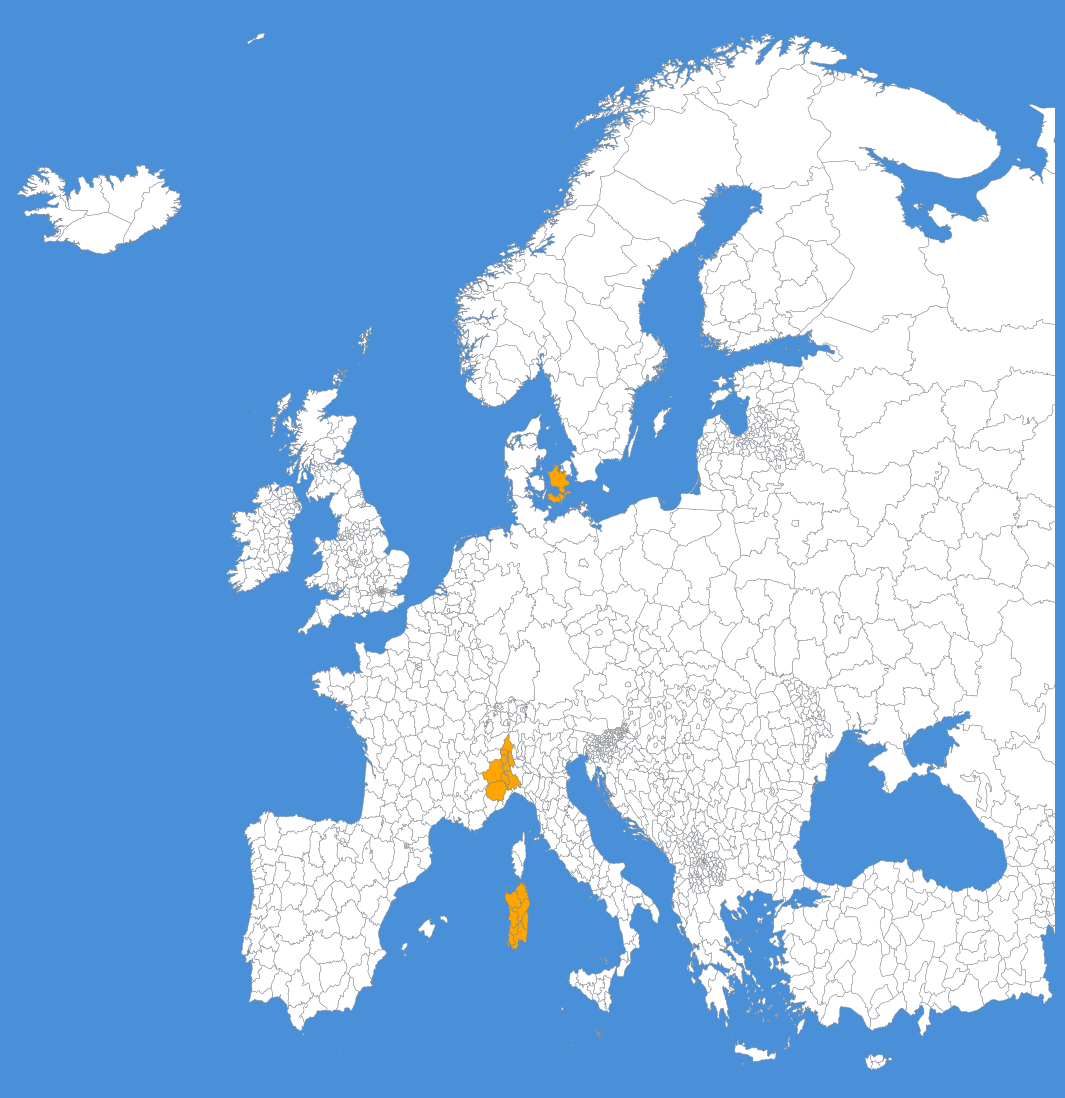

In [15]:
fig, ax = plt.subplots(figsize=(20, 14), facecolor='#4a90d9')  # increase second value for height
ax.set_facecolor('#4a90d9')
eu.plot(ax=ax, color=eu['color'].tolist(), edgecolor='#888888', linewidth=0.3)
ax.set_xlim(-25, 45)
ax.set_ylim(34, 72)
ax.axis('off')
plt.show()